# 05: SVR (Linear Kernel) Training

This notebook builds an SVR model (linear kernel) using the features prepared in Notebook 01 and follows the simple train/test structure used in Notebook 03.

## Chapter 4: Model Development

- Primary model: **Support Vector Regression (SVR)** with a **linear kernel**
- Cross-validation: standard **KFold** and **TimeSeriesSplit**
- Hyperparameter tuning: exhaustive **GridSearchCV** using **TimeSeriesSplit**


In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import KFold, TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [13]:
# Load feature definitions from Notebook 01 output
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)
feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

df.head()


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2021-05-28,121.575745,122.914885,-0.264829,7.693492e+07,10.999733,0.292013,60.467386,4.259409,-1.091632e+09,123.376990,125.065327,6.769302,121.253777
2021-06-01,121.253777,122.582663,0.627592,7.507536e+07,10.208658,0.273614,61.439864,4.241365,-1.166708e+09,123.235288,124.828883,6.054024,122.014755
2021-06-02,122.014755,122.469081,-1.215391,7.191607e+07,9.945317,0.262069,62.446581,4.224315,-1.238624e+09,123.126022,124.604140,5.490118,120.531799
2021-06-03,120.531799,122.081625,1.902212,7.277869e+07,9.084427,0.237350,63.543032,4.191806,-1.311403e+09,123.016170,124.363900,5.070034,122.824570
2021-06-04,122.824570,122.230214,0.007951,7.325682e+07,12.222482,0.239338,64.620172,4.188177,-1.238146e+09,122.900580,124.160692,4.522961,122.834335


In [14]:
# Train/test split (chronological) — same approach as Notebook 03
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Configured target:", target_col)
print("Configured features:", feature_cols)
print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")


Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 977
Test rows:  245
Train period: 2021-05-28 -> 2025-04-17
Test period:  2025-04-21 -> 2026-04-10


In [15]:
def regression_metrics(y_true, y_pred, model_name: str) -> pd.DataFrame:
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    return pd.DataFrame([metrics]).round(4)


In [16]:
# Primary model: SVR (linear kernel)
svr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="linear", C=1.0, epsilon=0.1)),
    ]
)

svr_model.fit(X_train, y_train)
svr_pred_train = svr_model.predict(X_train)
svr_pred_test = svr_model.predict(X_test)

print(regression_metrics(y_train, svr_pred_train, "SVR-linear (train)"))
print(regression_metrics(y_test, svr_pred_test, "SVR-linear (test)"))


                Model     MAE    RMSE    MAPE      R2
0  SVR-linear (train)  3.3985  4.6814  0.0195  0.9787
               Model     MAE   RMSE    MAPE      R2
0  SVR-linear (test)  4.6654  6.108  0.0195  0.9506


In [ ]:
# Exhaustive hyperparameter tuning with TimeSeriesSplit
param_grid = {
    "svr__C": np.logspace(-2, 3, 6),
    "svr__epsilon": np.logspace(-6, 0, 6),
    "svr__gamma": np.logspace(-6, 2, 6),
}

grid = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best CV RMSE:", -grid.best_score_)
grid.best_params_


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best CV RMSE: 5.312682055206633


{'svr__C': np.float64(10.0),
 'svr__epsilon': np.float64(0.01),
 'svr__gamma': np.float64(1e-05)}

In [18]:
# Top configurations (by CV RMSE)
results_df = pd.DataFrame(grid.cv_results_)
results_df["rmse"] = -results_df["mean_test_score"]
cols = ["rmse", "mean_fit_time", "params"]
results_df.sort_values("rmse", ascending=True)[cols].head(10)


,rmse,mean_fit_time,params
80,5.312682,0.044977,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
81,5.312682,0.044485,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
82,5.312682,0.045227,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
83,5.312682,0.045770,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
78,5.312682,0.044584,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
79,5.312682,0.044427,"{'svr__C': 10.0, 'svr__epsilon': 0.01, 'svr__g..."
77,5.321549,0.045475,"{'svr__C': 10.0, 'svr__epsilon': 0.001, 'svr__..."
76,5.321549,0.045504,"{'svr__C': 10.0, 'svr__epsilon': 0.001, 'svr__..."
75,5.321549,0.045726,"{'svr__C': 10.0, 'svr__epsilon': 0.001, 'svr__..."
74,5.321549,0.047494,"{'svr__C': 10.0, 'svr__epsilon': 0.001, 'svr__..."


In [19]:
# Final tuned model — evaluate on the held-out test period
best_svr_pipe = grid.best_estimator_
best_pred_test = best_svr_pipe.predict(X_test)

print(regression_metrics(y_test, best_pred_test, "SVR-linear (tuned via TimeSeriesSplit)"))


                                    Model     MAE    RMSE    MAPE      R2
0  SVR-linear (tuned via TimeSeriesSplit)  4.4296  5.8081  0.0186  0.9553


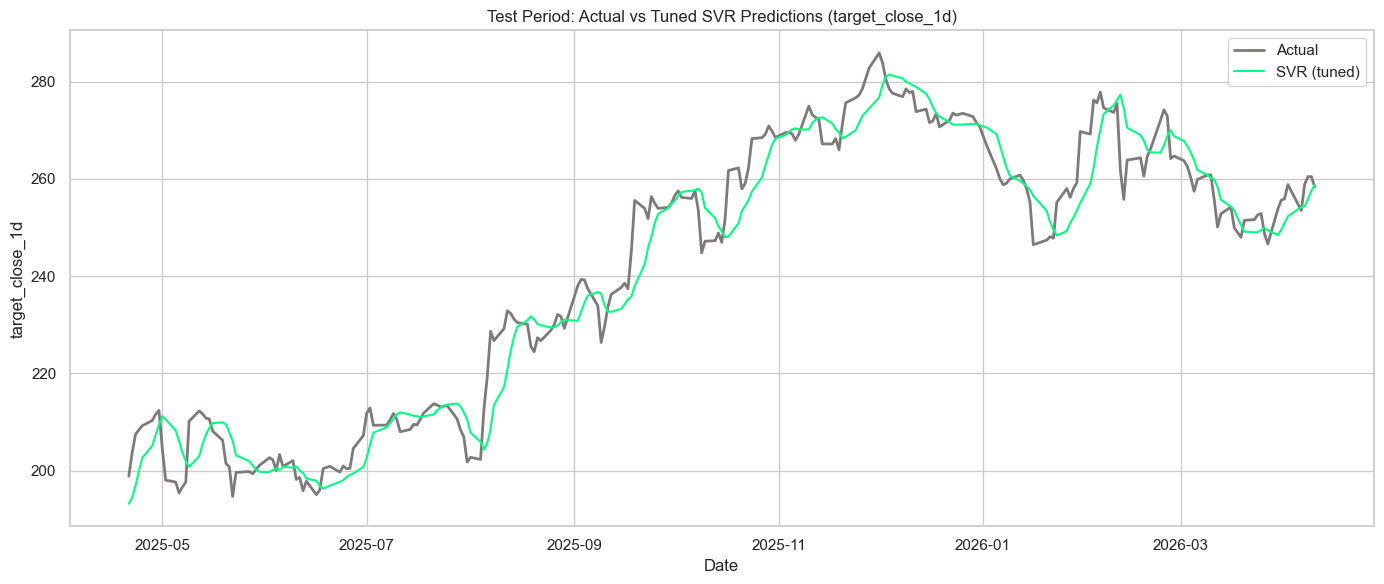

In [20]:
# Plot: Actual vs tuned model predictions
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["SVR_Linear_Tuned"] = best_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["SVR_Linear_Tuned"], label="SVR (tuned)", color="#00FF80")
plt.title(f"Test Period: Actual vs Tuned SVR Predictions ({target_col})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


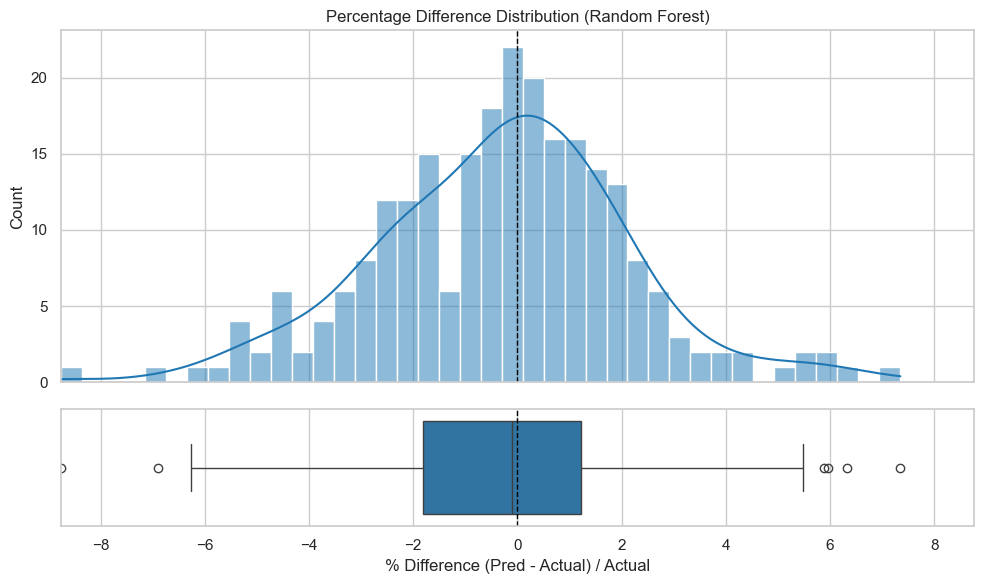

In [21]:
y_test_arr = np.asarray(y_test)
best_pred_arr = np.asarray(best_pred_test)
pct_diff = np.where(y_test_arr != 0, ((best_pred_arr - y_test_arr) / y_test_arr) * 100, np.nan)

valid_pct_diff = pct_diff[~np.isnan(pct_diff)]
if valid_pct_diff.size == 0:
    valid_pct_diff = np.array([0.0])
abs_limit = np.max(np.abs(valid_pct_diff))
if abs_limit == 0:
    abs_limit = 1

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(valid_pct_diff, bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Percentage Difference Distribution (Random Forest)")
axes[0].set_ylabel("Count")

sns.boxplot(x=valid_pct_diff, ax=axes[1], color="#1f77b4")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("% Difference (Pred - Actual) / Actual")

axes[0].set_xlim(-abs_limit, abs_limit)
axes[1].set_xlim(-abs_limit, abs_limit)

plt.tight_layout()
plt.show()


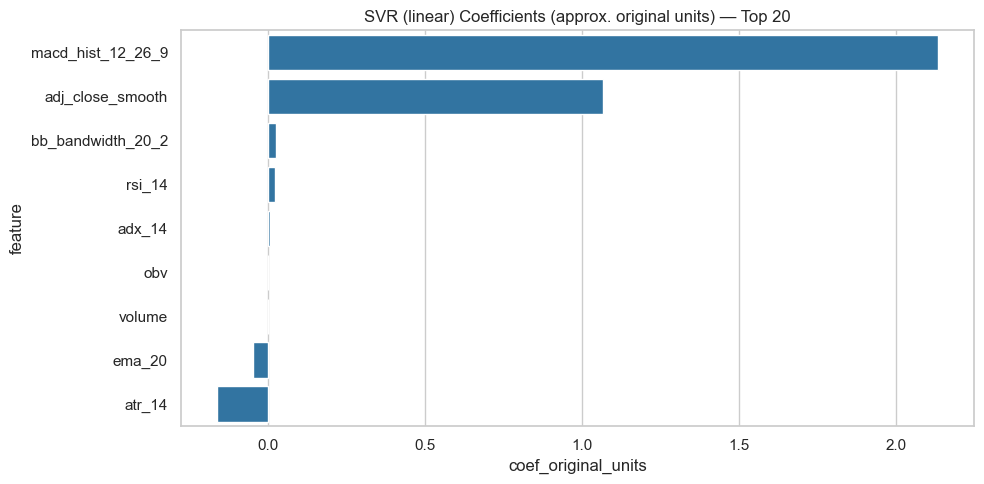

,feature,coef_scaled,coef_original_units
0,macd_hist_12_26_9,1.704323,2.131991e+00
1,adj_close_smooth,34.106494,1.067351e+00
2,bb_bandwidth_20_2,0.110653,2.826287e-02
3,rsi_14,0.665350,2.379296e-02
4,adx_14,0.159395,8.521983e-03
5,obv,-0.821176,-3.265092e-10
6,volume,-0.083698,-4.201057e-09
7,ema_20,-1.456035,-4.592900e-02
8,atr_14,-0.139263,-1.607835e-01


In [22]:
# Coefficients (linear kernel)
scaler = best_svr_pipe.named_steps["scaler"]
svr = best_svr_pipe.named_steps["svr"]

# Coefficients are learned on standardized features; convert to original feature units for readability
coef_scaled = svr.coef_.ravel()
coef_original_units = coef_scaled / scaler.scale_

coef_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "coef_scaled": coef_scaled,
            "coef_original_units": coef_original_units,
        }
    )
    .sort_values("coef_original_units", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(20), x="coef_original_units", y="feature", color="#1f77b4")
plt.title("SVR (linear) Coefficients (approx. original units) — Top 20")
plt.tight_layout()
plt.show()

coef_df
